# 22 - Feature Augmentation

**Section:** More on Data | **Prereqs:** `More on Data/DepthVsBreadth.ipynb` | **Next:** `More on Data/Handeling_Unbalanced_Data_Exact_Replication.ipynb`

*Feature* augmentation adds new columns to each sample (here, the distance of
each point from the origin). Distinguish it from *data* augmentation, which adds
new rows - more samples, via noise or transformations.

**The rule, and it is exact:**

| New feature | Does it help? |
|---|---|
| A linear combination of existing features | Never. A `Linear` layer can already form any linear combination - you have added nothing it could not compute. |
| A non-linear function of existing features (r, x*y, x^2) | Sometimes. It gives the network a shortcut it might not find on its own. |
| A genuinely new measurement | Almost always. |

Here the classes sit at different distances from the origin, so radius `r` is a
non-linear feature that happens to be nearly a class label on its own - which is
why it helps. On data where the classes are arranged differently, the same
feature would do nothing.

**Also here:** per-class accuracy. An overall number hides a model that is
excellent on two classes and hopeless on the third.

## Feature Augmentation

So we add non existing features to the data set according to the need of the data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F



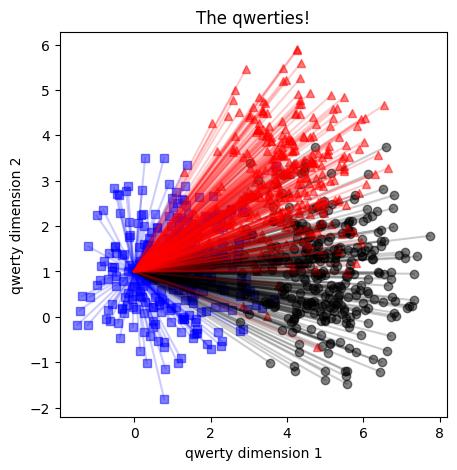

In [5]:
# Three clusters, 300 points each. The grey rays drawn from the origin are the
# hint: the classes sit at visibly different distances from (0,1).
nPerClust = 300
blur = 1

A = [ 1, 1 ]
B = [ 5, 1 ]
C = [ 4, 3 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]
c = [ C[0]+np.random.randn(nPerClust)*blur , C[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.hstack((  np.zeros((nPerClust)),
                         np.ones( (nPerClust)),
                       1+np.ones( (nPerClust))  ))

# concatanate into a matrix
data_np = np.hstack((a,b,c)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).long() # note: "long" format for CCE


# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs',alpha=.5)
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko',alpha=.5)
plt.plot(data[np.where(labels==2)[0],0],data[np.where(labels==2)[0],1],'r^',alpha=.5)

colors = 'bkr'
for i in range(len(data)):
  plt.plot([0, data[i,0]] , [1,data[i,1]], color=colors[labels[i]], alpha=0.2)

plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [23]:
# The augmented feature: Euclidean distance from the origin, sqrt(x^2 + y^2).
# NON-LINEAR in the inputs, which is the whole point - a linear feature would
# be redundant, since the first Linear layer can already build any of those.
# torch.cat along dim=1 appends it as a third column: (900,2) -> (900,3).
# Calculating euclidian distance:
distance = torch.sqrt(data[:,0]**2 + data[:,1]**2)

dataAug = torch.cat((data , distance.view(-1,1)) ,dim=1)

In [26]:
# Confirms the extra column: 3 features instead of 2.
dataAug.shape, data.shape

(torch.Size([900, 3]), torch.Size([900, 2]))

In [36]:
# Split, wrap, batch - the usual pipeline, now on the augmented data.
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader,TensorDataset

train_data,test_data, train_labels,test_labels = train_test_split(dataAug, labels, test_size=.1)

# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# finally, translate into dataloader objects
batchsize    = 16
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [69]:
# Input layer takes 3 features, not 2. Tiny network (8 units) on purpose: the
# question is whether the extra FEATURE helps, so model capacity is held down.
epochs = 50


def create_model():
  model = nn.Sequential (
      nn.Linear(3,8),
      nn.ReLU(),
      nn.Linear(8,8),
      nn.ReLU(),
      nn.Linear(8,3)
  )

  lossFunc = nn.CrossEntropyLoss()

  lr = 0.01

  optimizer = torch.optim.SGD(model.parameters(), lr=lr)

  return model, lossFunc, optimizer


In [70]:
# Training function with one addition: cat_losses records accuracy separately
# for each of the three classes, so a model that is strong on two and weak on
# the third cannot hide behind the average.
# (The name says 'losses' but these are per-class ACCURACIES.)
def train_model():

  classifier , lossFunc, optimizer = create_model()

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)
  cat_losses = torch.zeros(epochs, 3)

  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []


    for x,y in train_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean((torch.argmax(yhat,dim=1) == y).float()))

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      test_acc.append(100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y).float()))
      cat_losses[i, 0] =  100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y)[Y==0].float())
      cat_losses[i, 1] =  100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y)[Y==1].float())
      cat_losses[i, 2] =  100 * torch.mean((torch.argmax(classifier(X),dim=1) == Y)[Y==2].float())

  return train_acc, test_acc, losses, cat_losses


In [71]:
train_acc, test_acc, losses, cat_losses = train_model()

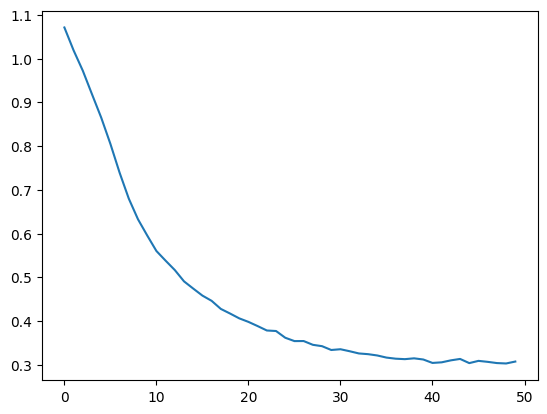

In [72]:
# Loss curve.
plt.plot(losses);

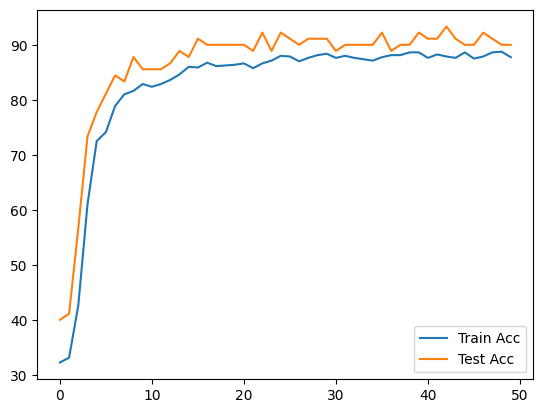

In [73]:
# Train vs test accuracy on the augmented data. Compare against a run with the
# distance column dropped - that is the experiment this notebook is really about.
plt.plot(train_acc, label='Train Acc')
plt.plot(test_acc , label='Test Acc')
plt.legend();

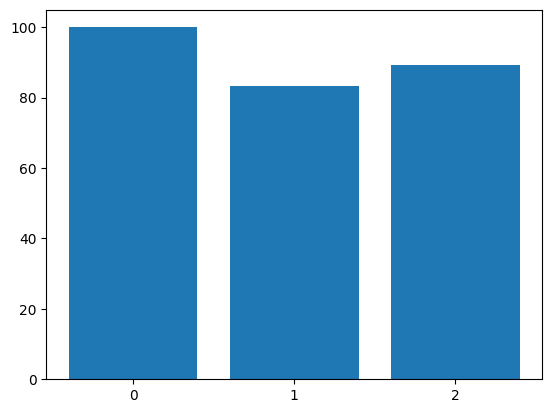

In [74]:
# Per-class accuracy at the final epoch. Look for one bar much shorter than the
# others: that is the class the model gave up on, which the overall number hides.
plt.bar(['0','1','2'], cat_losses[-1,:].detach());

In [75]:
# The same numbers exactly.
cat_losses[-1,:]

tensor([100.0000,  83.3333,  89.2857])

# Data Augmentation can generally be helpful to increase differentiabilty of the classes.


1.   No point of adding linear combinations of existing features
2.   Non-Linear features can be helpful but do not always work.
3.   So, we can add features that actually hold meaning on there own. Eg: Coherence in signal processing


